# Interpretation

FID Score: 228.854
Inception Score: 2.170 ± 0.326
- An FID of 228.9 is very high, indicating that the generated images are not similar to the real images in terms of features extracted by Inception v3.
- An IS of 2.2 is very low. It indicates that the generated images are not diverse and the Inception model does not assign high confidence to any particular class.

### Possible Reasons for Poor Performance
1. **Model Capacity**: The U-Net used is very shallow (only a few layers). This might be insufficient for capturing the complexity of the image distribution
2. **Training Time**: Only 5 epochs might not be enough for the model to converge.
3. The text conditioning might not be effectively utilized. The CLIP text embeddings are being used, but the U-Net might not be effectively combining the text and time embeddings.
4. **Hyperparameters**: Learning rate, batch size, etc. might need tuning.

### Steps for Improvement:

1. . **Increase Model Capacity**: Use a deeper U-Net architecture with residual blocks and attention. The current U-Net is very simple. Consider a U-Net with downsampling and upsampling blocks and skip connections.
2. **Train Longer**: Increase the number of epochs(50)
3. **Hyperparameter Tuning**:
   - Try a lower learning rate (e.g., 1e-4) or use a learning rate scheduler.
   - Increase batch size if possible (to 64 or 128) for more stable gradients.
- Instead of simply adding the time and text embeddings and then expanding spatially, consider using cross-attention between the text embedding and the image features. This is the approach used in Stable Diffusion.

# Tuning 1 Results
FID: 228.999 Inception Score: 1.915 ± 0.179
Key Observations:
No Improvement in FID:

FID almost same(228.854 -> 228.999)
- This suggests the core quality of generated images hasn't improved

Worse Inception Score(IS decreased from 2.170 to 1.915)
- Indicates the generated images have less recognizable features/diversity

Possible Causes:

Model capacity too high for dataset size (overfitting)

Training instability with complex architecture

Suboptimal learning rate schedule


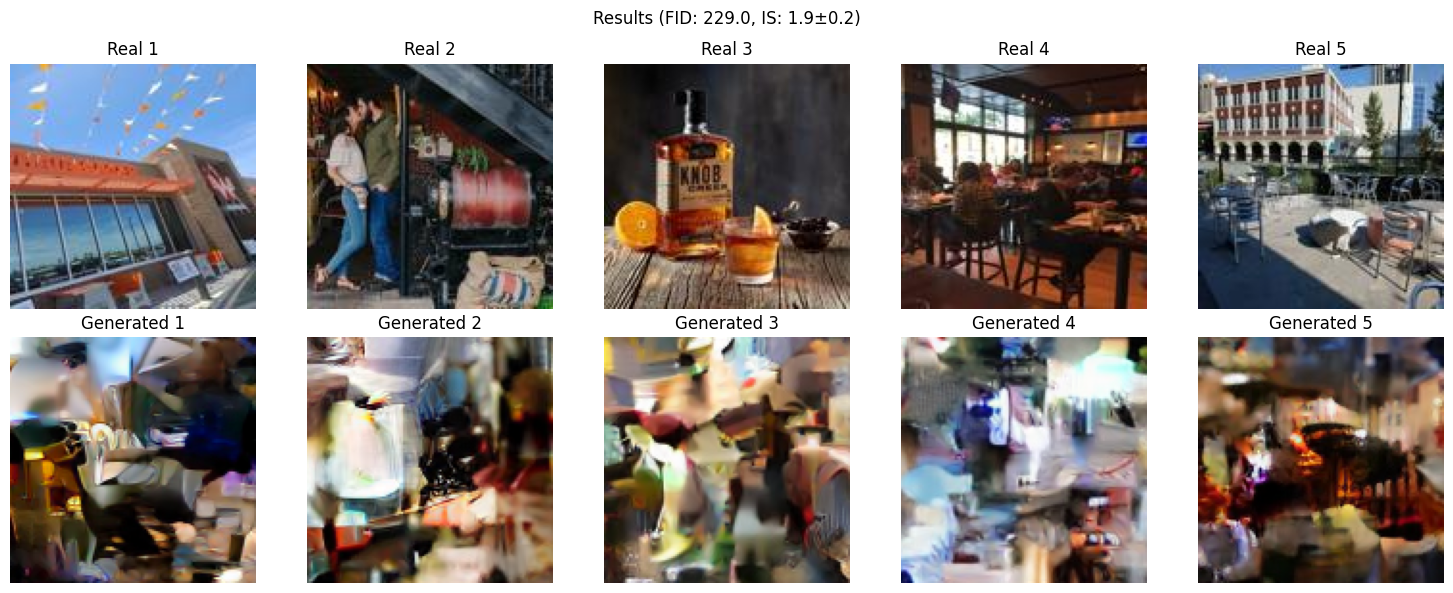

In [ ]:
!pip install torchmetrics torch-fidelity diffusers transformers accelerate
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torchvision import transforms
from torchvision.utils import save_image
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from diffusers import AutoencoderKL
from transformers import CLIPTokenizer, CLIPTextModel
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
config = {
    "image_dir": "/content/Assignment4/sampled/128_pix/split_photos_128/train",
    "caption_file": "/content/Assignment4/sampled/128_pix/128train_df_with_captions.csv",
    "output_dir": "./tuning_results"
}
os.makedirs(config["output_dir"], exist_ok=True)

In [4]:
# Hyperparameters
params = {
    "image_size": 128,
    "batch_size": 32,
    "grad_accum_steps": 2,  # Effective batch size = 64
    "lr": 1e-4,
    "epochs": 50,
    "timesteps": 1000,
    "sample_labels": ["food", "drink", "inside", "outside"],
    "samples_per_class": 500,
    "val_split": 0.2,
    "num_metric_samples": 500,
    "num_preview_samples": 5
}

In [5]:
class YelpCaptionedDataset(Dataset):
    def __init__(self, caption_csv, image_root, transform, tokenizer, max_samples_per_class=500):
        df = pd.read_csv(caption_csv)
        df = df[df["label"].isin(params["sample_labels"])]

        df = (df.groupby("label")
              .apply(lambda x: x.sample(n=min(max_samples_per_class, len(x)), random_state=42)
              .reset_index(drop=True)))

        self.df = df
        self.image_root = image_root
        self.transform = transform
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_root, row["label"], f"{row['photo_id']}.jpg")

        try:
            img = self.transform(Image.open(img_path).convert("RGB"))
        except:
            return self[(idx + 1) % len(self)]

        toks = self.tokenizer(
            row["caption"],
            padding="max_length",
            truncation=True,
            max_length=77,
            return_tensors="pt"
        )

        return {
            "pixel_values": img,
            "input_ids": toks.input_ids.squeeze(0),
            "caption": row["caption"]
        }

# Initialize dataset
transform = transforms.Compose([
    transforms.Resize((params["image_size"], params["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
full_ds = YelpCaptionedDataset(
    config["caption_file"],
    config["image_dir"],
    transform,
    tokenizer,
    params["samples_per_class"]
)

# Train/val split
val_size = int(params["val_split"] * len(full_ds))
train_ds, val_ds = random_split(full_ds, [len(full_ds)-val_size, val_size])
train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True)
val_loader = DataLoader(val_ds, batch_size=params["batch_size"])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/tmp/ipython-input-5-1534784114.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(max_samples_per_class, len(x)), random_state=42)


In [6]:
# Model Architecture
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.residual = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(x)
        h = self.norm1(h)
        emb_out = self.emb_proj(emb)[:, :, None, None]
        h = h + emb_out
        h = F.silu(h)
        h = self.conv2(h)
        h = self.norm2(h)
        return h + self.residual(x)

class AttentionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.qkv = nn.Conv2d(channels, channels*3, 1)
        self.out = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        qkv = self.qkv(self.norm(x))
        q, k, v = qkv.chunk(3, dim=1)

        q = q.view(B, C, -1)
        k = k.view(B, C, -1)
        v = v.view(B, C, -1)

        attn = torch.bmm(q.permute(0, 2, 1), k) * (C ** -0.5)
        attn = F.softmax(attn, dim=-1)
        out = torch.bmm(v, attn.permute(0, 2, 1))
        out = out.view(B, C, H, W)
        return self.out(out) + x

class TunedUNet(nn.Module):
    def __init__(self, text_embed_dim=512, time_emb_dim=64, cond_dim=256):
        super().__init__()
        # Time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim)
        )

        # Text conditioning
        self.text_proj = nn.Sequential(
            nn.Linear(text_embed_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim)
        )

        # Down blocks
        self.down1 = nn.ModuleList([
            ResidualBlock(4, 64, cond_dim),
            AttentionBlock(64),
            nn.Conv2d(64, 64, 3, 2, 1)
        ])

        self.down2 = nn.ModuleList([
            ResidualBlock(64, 128, cond_dim),
            AttentionBlock(128),
            nn.Conv2d(128, 128, 3, 2, 1)
        ])

        # Middle blocks
        self.mid = nn.ModuleList([
            ResidualBlock(128, 128, cond_dim),
            AttentionBlock(128),
            ResidualBlock(128, 128, cond_dim)
        ])

        # Up blocks
        self.up2 = nn.ModuleList([
            nn.ConvTranspose2d(128, 128, 4, 2, 1),
            ResidualBlock(256, 128, cond_dim),  # Skip connection
            AttentionBlock(128)
        ])

        self.up1 = nn.ModuleList([
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            ResidualBlock(128, 64, cond_dim),   # Skip connection
            AttentionBlock(64)
        ])

        # Output
        self.out = nn.Sequential(
            nn.GroupNorm(8, 64),
            nn.SiLU(),
            nn.Conv2d(64, 4, 3, padding=1)
        )

    def forward(self, x, t, txt_emb):
        # Process embeddings
        t_emb = self.time_mlp(t)
        txt_proj = self.text_proj(txt_emb)
        emb = t_emb + txt_proj

        # Down path
        x1 = self.down1[0](x, emb)
        x1 = self.down1[1](x1)
        x1_down = self.down1[2](x1)

        x2 = self.down2[0](x1_down, emb)
        x2 = self.down2[1](x2)
        x2_down = self.down2[2](x2)

        # Middle
        xm = self.mid[0](x2_down, emb)
        xm = self.mid[1](xm)
        xm = self.mid[2](xm, emb)

        # Up path
        xu = self.up2[0](xm)
        xu = torch.cat([xu, x2], dim=1)
        xu = self.up2[1](xu, emb)
        xu = self.up2[2](xu)

        xu = self.up1[0](xu)
        xu = torch.cat([xu, x1], dim=1)
        xu = self.up1[1](xu, emb)
        xu = self.up1[2](xu)

        return self.out(xu)

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)

In [7]:
# Diffusion Utilities
def q_sample_latent(z0, t, noise):
    """Forward diffusion in latent space"""
    ac = alphas_cumprod.to(z0.device)[t]
    ac = ac[:, None, None, None]
    oma = 1. - ac
    return torch.sqrt(ac) * z0 + torch.sqrt(oma) * noise

In [8]:
# Initialize models
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device).eval()
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()
unet = TunedUNet().to(device)

# Optimizer and scheduler
optimizer = AdamW(unet.parameters(), lr=params["lr"], weight_decay=1e-6)
scheduler = OneCycleLR(
    optimizer,
    max_lr=params["lr"],
    epochs=params["epochs"],
    steps_per_epoch=len(train_loader) // params["grad_accum_steps"]
)

# Noise schedule
betas = torch.linspace(1e-4, 0.02, params["timesteps"], device=device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

In [9]:
def validate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            latents = vae.encode(batch["pixel_values"].to(device)).latent_dist.sample() * 0.18215
            text_emb = text_encoder(batch["input_ids"].to(device)).pooler_output
            t = torch.randint(0, params["timesteps"], (latents.size(0),), device=device)
            noise = torch.randn_like(latents)
            noisy_latents = q_sample_latent(latents, t, noise)
            pred = model(noisy_latents, t.float(), text_emb)
            total_loss += F.mse_loss(pred, noise).item()
    return total_loss / len(loader)

best_val_loss = float('inf')
for epoch in range(params["epochs"]):
    unet.train()
    epoch_loss = 0
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{params['epochs']}")):
        # Forward pass
        with torch.no_grad():
            latents = vae.encode(batch["pixel_values"].to(device)).latent_dist.sample() * 0.18215
            text_emb = text_encoder(batch["input_ids"].to(device)).pooler_output

        t = torch.randint(0, params["timesteps"], (latents.size(0),), device=device)
        noise = torch.randn_like(latents)
        noisy_latents = q_sample_latent(latents, t, noise)

        # Predict and backprop
        pred = unet(noisy_latents, t.float(), text_emb)
        loss = F.mse_loss(pred, noise)
        loss.backward()

        # Gradient accumulation
        if (step + 1) % params["grad_accum_steps"] == 0:
            torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()
            scheduler.step()

        epoch_loss += loss.item()

    # Validation
    val_loss = validate(unet, val_loader)
    print(f"Epoch {epoch+1} | Train Loss: {epoch_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(unet.state_dict(), f"{config['output_dir']}/best_unet.pt")
        print(f"Saved new best model with val loss: {val_loss:.4f}")

Epoch 1/50: 100%|██████████| 50/50 [00:28<00:00,  1.75it/s]


Epoch 1 | Train Loss: 1.0803 | Val Loss: 1.0418
Saved new best model with val loss: 1.0418


Epoch 2/50: 100%|██████████| 50/50 [00:21<00:00,  2.31it/s]


Epoch 2 | Train Loss: 0.9998 | Val Loss: 0.9526
Saved new best model with val loss: 0.9526


Epoch 3/50: 100%|██████████| 50/50 [00:22<00:00,  2.25it/s]


...

Epoch 48 | Train Loss: 0.2077 | Val Loss: 0.2104


Epoch 49/50: 100%|██████████| 50/50 [00:22<00:00,  2.25it/s]


Epoch 49 | Train Loss: 0.2129 | Val Loss: 0.1985


Epoch 50/50: 100%|██████████| 50/50 [00:22<00:00,  2.26it/s]


Epoch 50 | Train Loss: 0.2076 | Val Loss: 0.2024


In [10]:
# Evaluation Code
@torch.no_grad()
def generate_images(captions, model, steps=500, batch_size=16):
    """Generate images from text prompts in batches"""
    model.eval()
    all_images = []

    for i in range(0, len(captions), batch_size):
        batch_captions = captions[i:i+batch_size]

        # Tokenize
        text_inputs = tokenizer(
            batch_captions,
            padding="max_length",
            truncation=True,
            max_length=77,
            return_tensors="pt"
        ).to(device)

        # Get embeddings
        text_emb = text_encoder(text_inputs.input_ids).pooler_output

        # Generate latents
        h = w = params["image_size"] // 8
        z = torch.randn(len(batch_captions), 4, h, w, device=device)

        for t in reversed(range(steps)):
            tt = torch.full((z.size(0),), t, device=device, dtype=torch.long)
            eps = model(z, tt.float(), text_emb)

            beta = betas[t]
            alpha = alphas[t]
            a_hat = alphas_cumprod[t]

            noise = torch.randn_like(z) if t > 0 else 0
            z = (1/torch.sqrt(alpha)) * (
                z - ((1-alpha)/torch.sqrt(1-a_hat)) * eps
            ) + torch.sqrt(beta) * noise

        # Decode to image space
        imgs = vae.decode(z / 0.18215).sample.clamp(-1, 1)
        all_images.append(imgs)

    return torch.cat(all_images)

In [11]:
# Load best model
unet.load_state_dict(torch.load(f"{config['output_dir']}/best_unet.pt"))
unet.eval()

# Get validation samples
val_indices = torch.randperm(len(val_ds))[:params["num_metric_samples"]].tolist()
real_images = torch.stack([val_ds[i]["pixel_values"] for i in val_indices]).to(device)
captions = [val_ds[i]["caption"] for i in val_indices]

# Generate images
print("Generating evaluation samples...")
fake_images = generate_images(captions, unet)

# Calculate metrics
print("Computing metrics...")
fid = FrechetInceptionDistance(normalize=True).to(device)
isc = InceptionScore(normalize=True).to(device)

# Prepare images (convert to [0,1] range)
real_images = (real_images + 1) / 2
fake_images = (fake_images + 1) / 2

fid.update(real_images, real=True)
fid.update(fake_images, real=False)
isc.update(fake_images)

fid_score = fid.compute().item()
isc_mean, isc_std = isc.compute()

print(f"\n{'='*50}")
print(f"FID Score: {fid_score:.3f}")
print(f"Inception Score: {isc_mean:.3f} ± {isc_std:.3f}")
print(f"{'='*50}")

Generating evaluation samples...
Computing metrics...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 125MB/s]
/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)



FID Score: 228.999
Inception Score: 1.915 ± 0.179


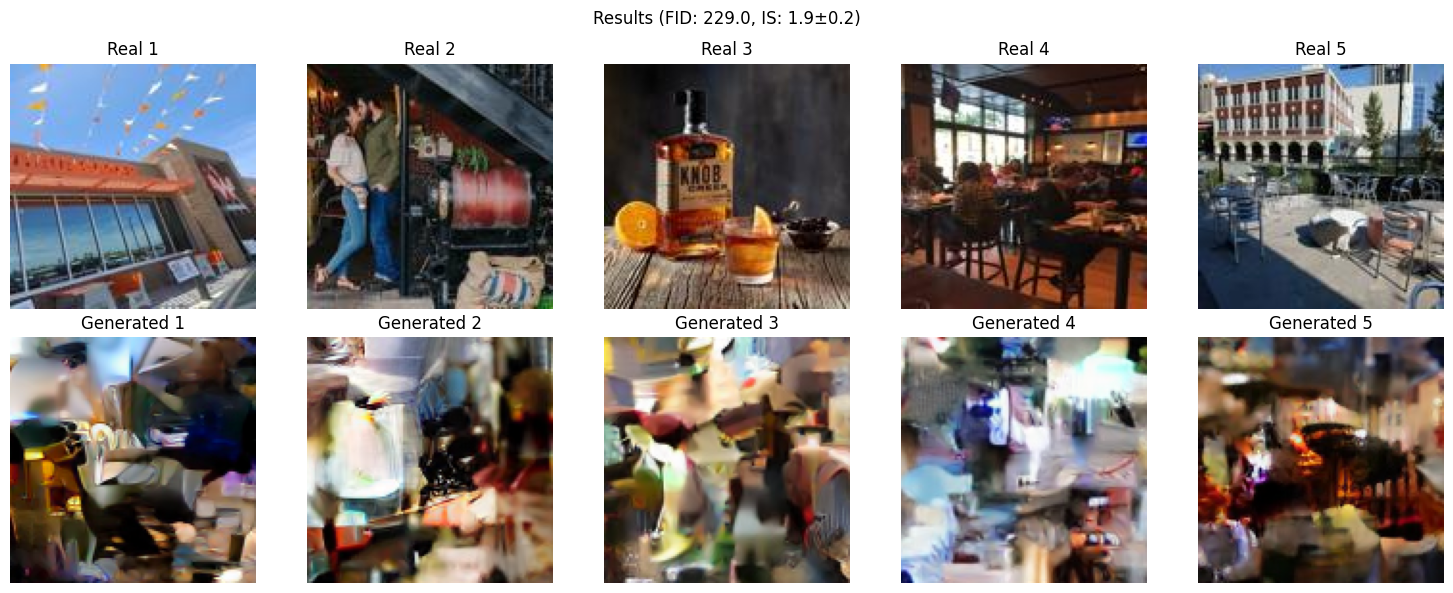

In [12]:
# Save preview
preview_real = real_images[:params["num_preview_samples"]].cpu()
preview_fake = fake_images[:params["num_preview_samples"]].cpu()

save_image(preview_real, f"{config['output_dir']}/real_samples.png", nrow=params["num_preview_samples"])
save_image(preview_fake, f"{config['output_dir']}/generated_samples.png", nrow=params["num_preview_samples"])

# Display results
fig, ax = plt.subplots(2, params["num_preview_samples"], figsize=(15, 6))
for i in range(params["num_preview_samples"]):
    ax[0,i].imshow(preview_real[i].permute(1,2,0).clamp(0,1))
    ax[0,i].set_title(f"Real {i+1}")
    ax[0,i].axis('off')

    ax[1,i].imshow(preview_fake[i].permute(1,2,0).clamp(0,1))
    ax[1,i].set_title(f"Generated {i+1}")
    ax[1,i].axis('off')

plt.suptitle(f"Results (FID: {fid_score:.1f}, IS: {isc_mean:.1f}±{isc_std:.1f})")
plt.tight_layout()
plt.savefig(f"{config['output_dir']}/comparison.png", dpi=120)
plt.show()